In [2]:
import pandas as pd
import re

In [3]:
df = pd.read_csv('/kaggle/input/datasets/ashishjangra27/imdb-movies-dataset/movies.csv')

/tmp/ipykernel_57/4034651097.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/datasets/ashishjangra27/imdb-movies-dataset/movies.csv')


In [4]:
df

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
0,tt4710316,Best in Sex: 2015 AVN Awards,(2015 TV Special),4.0,TV-MA,94 min,"Adult, News",124.0,0,nm1624094,Gary Miller,"nm4766272,nm2670531,nm4920605,nm6284246","Farrah Laurel Abraham,Asa Akira,Anikka Albrite...",The hottest adult stars and top adult movies a...
1,tt1281857,Naughty Novelist,(2008 Video),3.8,Not Certified,88 min,Adult,174.0,0,nm0045256,John Bacchus,"nm0128986,nm1969196,nm0451160,nm6130462","Darian Caine,Jackie Stevens,A.J. Khan,Arrora",Darian is a successful journalist but when she...
2,tt2294954,2011 AVN Awards Show,(2011 TV Special),5.7,Not Certified,83 min,"Adult, News",39.0,0,"nm1624094,nm0754845","Gary Miller,Timothy E. Sabo","nm2200343,nm2670531,nm1267549,nm3585599","Aubrey Addams,Asa Akira,Monique Alexander,Rave...",Add a Plot
3,tt6843596,Best in Sex: 2017 AVN Awards,(2017 TV Special),4.9,TV-MA,87 min,"Adult, News",225.0,0,nm1624094,Gary Miller,"nm5221471,nm2670531,nm4920605,nm3038816","Amirah Adara,Asa Akira,Anikka Albrite,Britney ...","Considered the industry's highest honor, the A..."
4,tt3705604,AVN Awards 2014,(2014 TV Special),6.7,R,82 min,"Adult, News",101.0,0,nm1624094,Gary Miller,"nm2670531,nm4920605,nm6284246,nm3992720","Asa Akira,Anikka Albrite,August Ames,Jessie An...",Erotic filmmaking superstars Chanel Preston an...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2590927,tt9898738,Alla mot alla med Filip och Fredrik,(2019– ),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,"nm1229568,nm1229296,nm10518401,nm0423935","Filip Hammar,Fredrik Wikingsson,Emma Frans,Eri...",Add a Plot
2590928,tt9898742,Alla mot alla med Filip och Fredrik,(2019– ),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,"nm1229568,nm1229296,nm0423935,nm2644274","Filip Hammar,Fredrik Wikingsson,Erik Johansson...",Add a Plot
2590929,tt9898746,Alla mot alla med Filip och Fredrik,(2019– ),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,"nm1229568,nm1229296,nm3355023,nm7732727","Filip Hammar,Fredrik Wikingsson,Hanna Hellquis...",Add a Plot
2590930,tt9898802,Aslan Max Eglence Fabrikasi,(2016–2017),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,Anonymous,nm0000000,Add a Plot


In [5]:
df.head()

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
0,tt4710316,Best in Sex: 2015 AVN Awards,(2015 TV Special),4.0,TV-MA,94 min,"Adult, News",124.0,0,nm1624094,Gary Miller,"nm4766272,nm2670531,nm4920605,nm6284246","Farrah Laurel Abraham,Asa Akira,Anikka Albrite...",The hottest adult stars and top adult movies a...
1,tt1281857,Naughty Novelist,(2008 Video),3.8,Not Certified,88 min,Adult,174.0,0,nm0045256,John Bacchus,"nm0128986,nm1969196,nm0451160,nm6130462","Darian Caine,Jackie Stevens,A.J. Khan,Arrora",Darian is a successful journalist but when she...
2,tt2294954,2011 AVN Awards Show,(2011 TV Special),5.7,Not Certified,83 min,"Adult, News",39.0,0,"nm1624094,nm0754845","Gary Miller,Timothy E. Sabo","nm2200343,nm2670531,nm1267549,nm3585599","Aubrey Addams,Asa Akira,Monique Alexander,Rave...",Add a Plot
3,tt6843596,Best in Sex: 2017 AVN Awards,(2017 TV Special),4.9,TV-MA,87 min,"Adult, News",225.0,0,nm1624094,Gary Miller,"nm5221471,nm2670531,nm4920605,nm3038816","Amirah Adara,Asa Akira,Anikka Albrite,Britney ...","Considered the industry's highest honor, the A..."
4,tt3705604,AVN Awards 2014,(2014 TV Special),6.7,R,82 min,"Adult, News",101.0,0,nm1624094,Gary Miller,"nm2670531,nm4920605,nm6284246,nm3992720","Asa Akira,Anikka Albrite,August Ames,Jessie An...",Erotic filmmaking superstars Chanel Preston an...


In [6]:
df.tail()

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
2590927,tt9898738,Alla mot alla med Filip och Fredrik,(2019– ),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,"nm1229568,nm1229296,nm10518401,nm0423935","Filip Hammar,Fredrik Wikingsson,Emma Frans,Eri...",Add a Plot
2590928,tt9898742,Alla mot alla med Filip och Fredrik,(2019– ),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,"nm1229568,nm1229296,nm0423935,nm2644274","Filip Hammar,Fredrik Wikingsson,Erik Johansson...",Add a Plot
2590929,tt9898746,Alla mot alla med Filip och Fredrik,(2019– ),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,"nm1229568,nm1229296,nm3355023,nm7732727","Filip Hammar,Fredrik Wikingsson,Hanna Hellquis...",Add a Plot
2590930,tt9898802,Aslan Max Eglence Fabrikasi,(2016–2017),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,Anonymous,nm0000000,Add a Plot
2590931,tt9898812,Aslan Max Eglence Fabrikasi,(2016–2017),11.0,Not Certified,0 min,Game-Show,0,0,"/name/nm10518392/,/name/nm4756662/","Oguz Bayram,Ferman Akgül",nm4756662,Ferman Akgül,Add a Plot


In [7]:
len(df)

2590932

In [8]:
df['rating']

0           4.0
1           3.8
2           5.7
3           4.9
4           6.7
           ... 
2590927    11.0
2590928    11.0
2590929    11.0
2590930    11.0
2590931    11.0
Name: rating, Length: 2590932, dtype: float64

In [9]:
df.isnull()

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2590927,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2590928,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2590929,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2590930,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

id                0
name              4
year              0
rating            0
certificate       0
duration          0
genre             0
votes             0
gross_income      0
directors_id      0
directors_name    0
stars_id          0
stars_name        0
description       0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2590932 entries, 0 to 2590931
Data columns (total 14 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              object 
 1   name            object 
 2   year            object 
 3   rating          float64
 4   certificate     object 
 5   duration        object 
 6   genre           object 
 7   votes           object 
 8   gross_income    object 
 9   directors_id    object 
 10  directors_name  object 
 11  stars_id        object 
 12  stars_name      object 
 13  description     object 
dtypes: float64(1), object(13)
memory usage: 276.7+ MB


In [12]:
df.describe()

,rating
count,2.590932e+06
mean,1.000326e+01
std,1.885600e+00
min,1.000000e+00
25%,1.100000e+01
50%,1.100000e+01
75%,1.100000e+01
max,1.100000e+01


In [13]:
df.isnull().sum()

id                0
name              4
year              0
rating            0
certificate       0
duration          0
genre             0
votes             0
gross_income      0
directors_id      0
directors_name    0
stars_id          0
stars_name        0
description       0
dtype: int64

2.1)DATA CLEANING# 
* Removing null

In [14]:
df.dropna()

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
0,tt4710316,Best in Sex: 2015 AVN Awards,(2015 TV Special),4.0,TV-MA,94 min,"Adult, News",124.0,0,nm1624094,Gary Miller,"nm4766272,nm2670531,nm4920605,nm6284246","Farrah Laurel Abraham,Asa Akira,Anikka Albrite...",The hottest adult stars and top adult movies a...
1,tt1281857,Naughty Novelist,(2008 Video),3.8,Not Certified,88 min,Adult,174.0,0,nm0045256,John Bacchus,"nm0128986,nm1969196,nm0451160,nm6130462","Darian Caine,Jackie Stevens,A.J. Khan,Arrora",Darian is a successful journalist but when she...
2,tt2294954,2011 AVN Awards Show,(2011 TV Special),5.7,Not Certified,83 min,"Adult, News",39.0,0,"nm1624094,nm0754845","Gary Miller,Timothy E. Sabo","nm2200343,nm2670531,nm1267549,nm3585599","Aubrey Addams,Asa Akira,Monique Alexander,Rave...",Add a Plot
3,tt6843596,Best in Sex: 2017 AVN Awards,(2017 TV Special),4.9,TV-MA,87 min,"Adult, News",225.0,0,nm1624094,Gary Miller,"nm5221471,nm2670531,nm4920605,nm3038816","Amirah Adara,Asa Akira,Anikka Albrite,Britney ...","Considered the industry's highest honor, the A..."
4,tt3705604,AVN Awards 2014,(2014 TV Special),6.7,R,82 min,"Adult, News",101.0,0,nm1624094,Gary Miller,"nm2670531,nm4920605,nm6284246,nm3992720","Asa Akira,Anikka Albrite,August Ames,Jessie An...",Erotic filmmaking superstars Chanel Preston an...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2590927,tt9898738,Alla mot alla med Filip och Fredrik,(2019– ),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,"nm1229568,nm1229296,nm10518401,nm0423935","Filip Hammar,Fredrik Wikingsson,Emma Frans,Eri...",Add a Plot
2590928,tt9898742,Alla mot alla med Filip och Fredrik,(2019– ),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,"nm1229568,nm1229296,nm0423935,nm2644274","Filip Hammar,Fredrik Wikingsson,Erik Johansson...",Add a Plot
2590929,tt9898746,Alla mot alla med Filip och Fredrik,(2019– ),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,"nm1229568,nm1229296,nm3355023,nm7732727","Filip Hammar,Fredrik Wikingsson,Hanna Hellquis...",Add a Plot
2590930,tt9898802,Aslan Max Eglence Fabrikasi,(2016–2017),11.0,Not Certified,0 min,Game-Show,0,0,Anonymous,nm0000000,Anonymous,nm0000000,Add a Plot


2.2)DATA CLEANING# 
Cleaning year coloumn

In [15]:
from tqdm import tqdm
df['year'] = df['year'].astype(str)

start_years = []
end_years = []

for year in tqdm(df['year']):
    result = re.findall(r"\d{4}", year)

    if len(result) >= 2:
        start_years.append(result[0])
        end_years.append(result[1])

    elif len(result) == 1:
        start_years.append(result[0])

        
        if '–' in year or '-' in year:
            end_years.append('0')   # ongoing
        else:
            end_years.append(result[0])

    else:
        start_years.append('0')
        end_years.append('0')

df['start_years'] = start_years
df['end_years'] = end_years

df['start_years'] = df['start_years'].astype(int)
df['end_years'] = df['end_years'].astype(int)
df.head()

100%|██████████| 2590932/2590932 [00:02<00:00, 885871.99it/s]


,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description,start_years,end_years
0,tt4710316,Best in Sex: 2015 AVN Awards,(2015 TV Special),4.0,TV-MA,94 min,"Adult, News",124.0,0,nm1624094,Gary Miller,"nm4766272,nm2670531,nm4920605,nm6284246","Farrah Laurel Abraham,Asa Akira,Anikka Albrite...",The hottest adult stars and top adult movies a...,2015,2015
1,tt1281857,Naughty Novelist,(2008 Video),3.8,Not Certified,88 min,Adult,174.0,0,nm0045256,John Bacchus,"nm0128986,nm1969196,nm0451160,nm6130462","Darian Caine,Jackie Stevens,A.J. Khan,Arrora",Darian is a successful journalist but when she...,2008,2008
2,tt2294954,2011 AVN Awards Show,(2011 TV Special),5.7,Not Certified,83 min,"Adult, News",39.0,0,"nm1624094,nm0754845","Gary Miller,Timothy E. Sabo","nm2200343,nm2670531,nm1267549,nm3585599","Aubrey Addams,Asa Akira,Monique Alexander,Rave...",Add a Plot,2011,2011
3,tt6843596,Best in Sex: 2017 AVN Awards,(2017 TV Special),4.9,TV-MA,87 min,"Adult, News",225.0,0,nm1624094,Gary Miller,"nm5221471,nm2670531,nm4920605,nm3038816","Amirah Adara,Asa Akira,Anikka Albrite,Britney ...","Considered the industry's highest honor, the A...",2017,2017
4,tt3705604,AVN Awards 2014,(2014 TV Special),6.7,R,82 min,"Adult, News",101.0,0,nm1624094,Gary Miller,"nm2670531,nm4920605,nm6284246,nm3992720","Asa Akira,Anikka Albrite,August Ames,Jessie An...",Erotic filmmaking superstars Chanel Preston an...,2014,2014


<Axes: xlabel='start_years'>

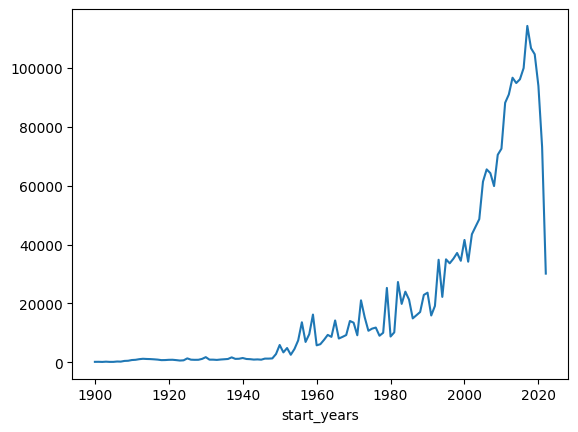

In [16]:
df[(df['start_years']>= 1900) & (df['start_years']<= 2022)]['start_years'].value_counts().sort_index().plot(kind ='line')

2.3) Clean Votes coloumn

In [17]:
df['votes'] = (
    pd.to_numeric(
        df['votes'].astype(str).str.replace(',', '', regex=False),
        errors='coerce'
    )
    .fillna(0)
    .astype(int)
)

2.4) Clean Genre Coloumn

In [18]:
from tqdm import tqdm
genres = list(df['genre'])
clean_genre = []
for genre in tqdm(genres):
    clean_genre += genre.replace(' ','').split(',')

100%|██████████| 2590932/2590932 [00:01<00:00, 2284748.82it/s]


In [19]:
df['genre'].str.replace(' ','').str.split(',').explode().value_counts()

genre
Drama          516399
Comedy         452896
Short          394411
Animation      388765
Adventure      348034
Game-Show      324968
Action         312766
Crime          271023
Family         243254
Sport          241713
Reality-TV     237513
Music          230635
Mystery        174146
Horror         164013
Documentary    155475
Thriller       151520
History        148421
Fantasy        147531
Romance         99986
Sci-Fi          98745
Biography       93549
Musical         84862
Talk-Show       82860
News            48059
War             32128
Western         29232
Film-Noir         771
Adult              50
Name: count, dtype: int64

3.# )Data analysis


* Trend of movies and series over the years

/tmp/ipykernel_57/3859216745.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_[(df['start_years']>= 1900) &(df['start_years']<= 2022)]['start_years'].value_counts().sort_index().plot(kind ='line')
/tmp/ipykernel_57/3859216745.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_[(df['start_years']>= 1900) &(df['start_years']<= 2022)]['start_years'].value_counts().sort_index().plot(kind ='line')


<Axes: xlabel='start_years'>

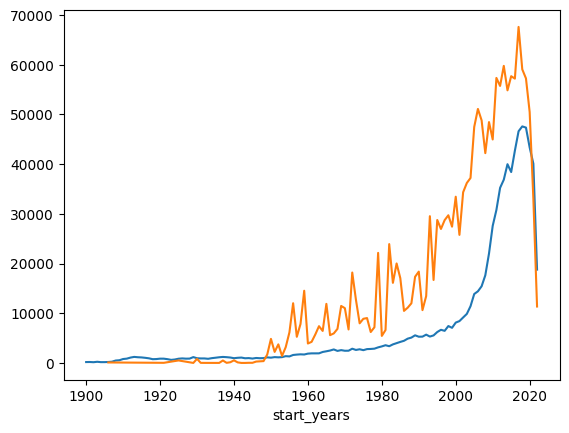

In [20]:
df_ = df[df['start_years'] == df['end_years']]

df_[(df['start_years']>= 1900) &(df['start_years']<= 2022)]['start_years'].value_counts().sort_index().plot(kind ='line')

df_ = df[df['start_years'] != df['end_years']]

df_[(df['start_years']>= 1900) &(df['start_years']<= 2022)]['start_years'].value_counts().sort_index().plot(kind ='line')




* votes per year

In [21]:
years = []
votes = []

for year in range(1900, 2024):
    years.append(year)
    votes.append(int(df[df['start_years'] == year]['votes'].sum()))

df_year_stats = pd.DataFrame()
df_year_stats['years'] = years
df_year_stats['votes'] = votes   # FIXED

In [22]:
df_year_stats

,years,votes
0,1900,9780
1,1901,14298
2,1902,54409
3,1903,41370
4,1904,11626
...,...,...
119,2019,35458802
120,2020,18090184
121,2021,25626553
122,2022,7283379


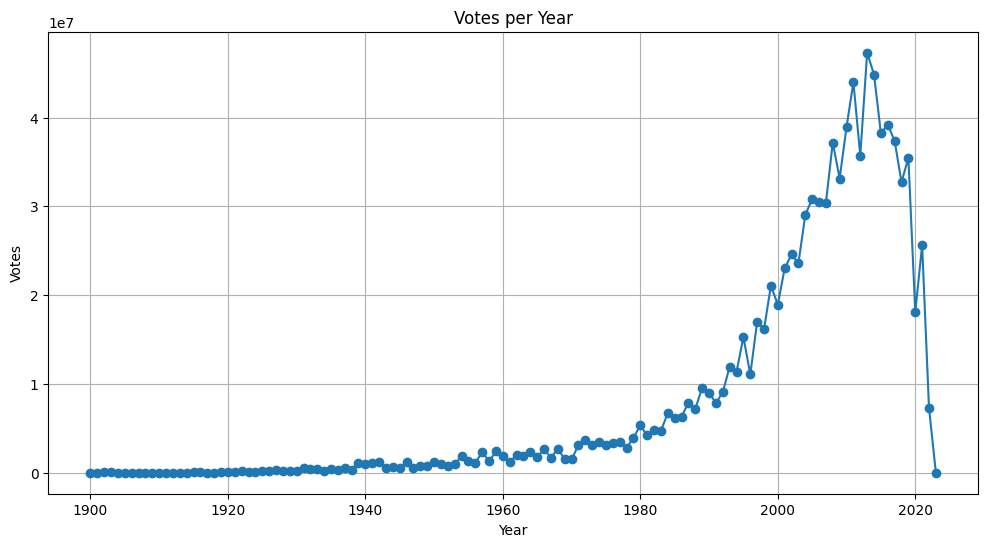

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_year_stats['years'], df_year_stats['votes'], marker='o')

plt.title("Votes per Year")
plt.xlabel("Year")
plt.ylabel("Votes")
plt.grid(True)

plt.show()

📅 Trends in content release over time

<Axes: ylabel='count'>

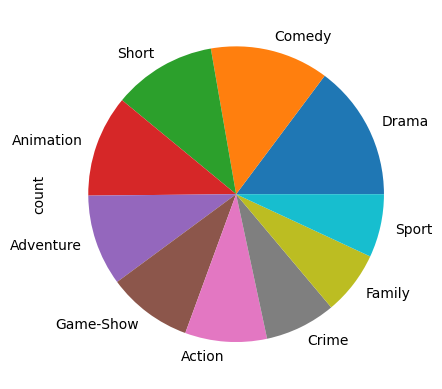

In [24]:
df['genre'].str.replace(' ','').str.split(',').explode().value_counts().head(10).plot(kind='pie')

<Axes: ylabel='count'>

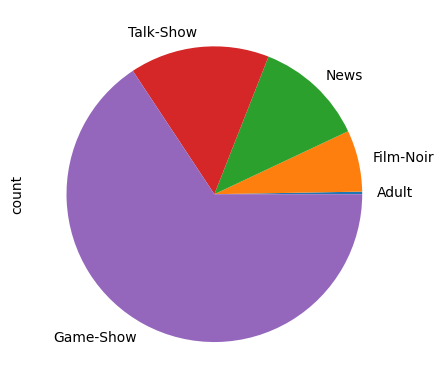

In [25]:
unique_genres = df_["genre"].str. split(',').explode() .unique()

df_= df[(df['start_years'] >=1900) & (df['start_years'] <= 2022)]
df_ = df_[df_['start_years'] == df_['end_years' ]]
df_ = df_[df_['genre' ] != 'Talk-Show' ]
df_['genre'].str.split(', ').explode().value_counts().sort_values(ascending = True).head(5).plot(kind = 'pie')

<Axes: ylabel='count'>

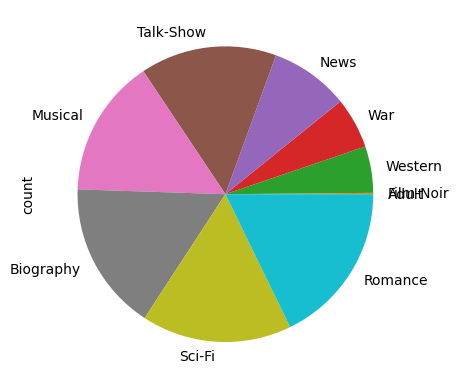

In [26]:
df_ = df[(df['start_years' ] >= 1900) & (df['start_years' ] <= 2022)]
df_['genre' ].str. split(', ').explode().value_counts().sort_values(ascending = True).head(10).plot(kind = 'pie')

In [27]:
unique_genres

array(['Adult', ' Romance', ' Crime', ' Drama', 'Animation', ' Adult',
       'Action', 'Crime', ' Adventure', ' Comedy', ' Thriller',
       ' Mystery', 'Comedy', ' Horror', ' Fantasy', 'Documentary',
       'Biography', ' History', ' Action', 'Adventure', 'Drama',
       ' Musical', ' Short', ' Sci-Fi', ' Family', ' Western', 'Short',
       ' Biography', ' Reality-TV', ' Music', ' Animation', ' Talk-Show',
       ' Sport', ' Documentary', ' Game-Show', ' News', 'Horror',
       'Thriller', 'Mystery', 'Reality-TV', ' Film-Noir', ' War',
       'Fantasy', 'News', 'Game-Show', 'Family', 'History', 'Sci-Fi',
       'Talk-Show', 'War', 'Music', 'Musical', 'Sport', 'Romance',
       'Western'], dtype=object)

In [34]:
freq = []

for genre in tqdm(unique_genres):
    freq.append(int(df[df['genre'].str.contains(genre)] ['votes' ].sum()))



100%|██████████| 55/55 [00:29<00:00,  1.87it/s]


In [54]:
import pandas as pd
df_ = pd.DataFrame()
df_['genre' ] = unique_genres
df_['freq' ] = freq

In [52]:
df_. sort_values(by = 'freq')

,genre,freq
5,Adult,1133
0,Adult,2157
33,Documentary,36559
35,News,288437
43,News,309134
31,Talk-Show,464531
48,Talk-Show,464561
30,Animation,642497
34,Game-Show,813010
44,Game-Show,1772558


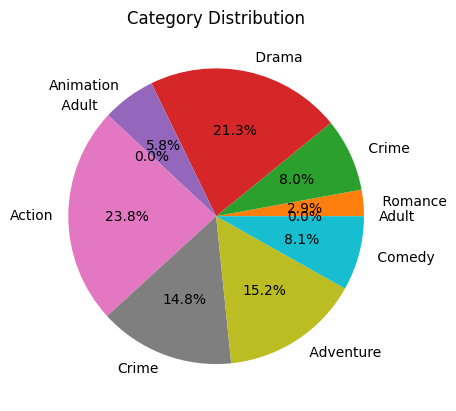

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.pie(freq[:10], labels=unique_genres[:10], autopct='%1.1f%%')
plt.title("Category Distribution")
plt.show()

In [78]:
kids = ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G', 'G', 'GA', 'E', 'EC', 'CE', 'K-A', '6+']

family = ['PG', 'PG-13', 'TV-PG', 'TV-13', 'GP', 'M', 'M/PG', 'Approved', 'Passed', 'Open', '12', 'PG-12', 'T', 'E10+']

adult = [ 'R', 'NC-17', 'X', 'TV-14', 'TV-MA', 'MA-13', 'MA-17', '18', 'R-12', 'R-15', 'R-18', 'AO', 'Banned', '(Banned)',
'Not Rated', 'Unrated', 'Not Certified']


In [91]:
category_map = {c: 'Kids' for c in kids}
category_map.update({c: 'Family' for c in family})
category_map.update({c: 'Adult' for c in adult})

df['content_category'] = df['certificate' ]. map(category_map)


<Axes: ylabel='count'>

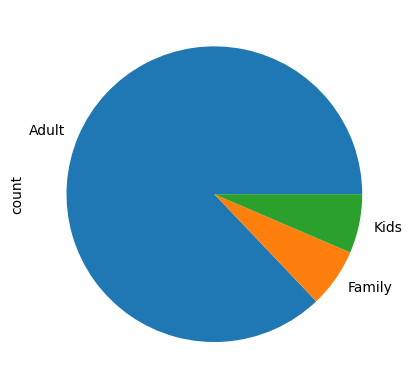

In [92]:
df['content_category' ].value_counts() .plot(kind = 'pie')

In [96]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

df_= df[df['content_category' ] != 'NC' ]

def plot_year(year) :
    data = df_[df_['start_years'] == year].groupby('content_category' ) ['votes' ].sum()
    plt.figure()
    plt.pie(data, labels=data.index, autopct='%1.1f%%')
    plt.title(str(year))
    plt.show()

interact(plot_year,
    year=IntSlider(min = 1900,
    max=2022,
    step=1,
    value=df_['start_years'].min()))

interactive(children=(IntSlider(value=1900, description='year', max=2022, min=1900), Output()), _dom_classes=(…

<function __main__.plot_year(year)>

<Axes: ylabel='votes'>

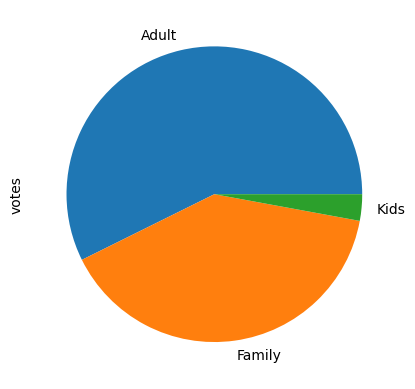

In [93]:
df_ = df[df['content_category' ] != 'NC' ]

df.groupby('content_category') ['votes' ].sum().plot(kind = 'pie')